In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, KFold
from scipy.cluster.hierarchy import dendrogram, linkage


In [14]:
# Step 1: Load dataset
df = pd.read_csv("Mall_Customers.csv")
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
# Step 2: Preprocessing
df['Genre'] = LabelEncoder().fit_transform(df['Genre'])  # Male=1, Female=0
print("Missing values:\n", df.isnull().sum())


Missing values:
 CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [5]:
# Step 3: Select relevant features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [6]:
# Step 4: Scale and split data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test = train_test_split(X_scaled, test_size=0.25, random_state=42)

In [7]:
# Step 5: K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42)
train_labels = kmeans.fit_predict(X_train)
test_labels = kmeans.predict(X_test)
sil_kmeans = silhouette_score(X_train, train_labels)
print(f"K-Means Silhouette Score: {sil_kmeans:.3f}")

K-Means Silhouette Score: 0.554


C:\Users\Anirudh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


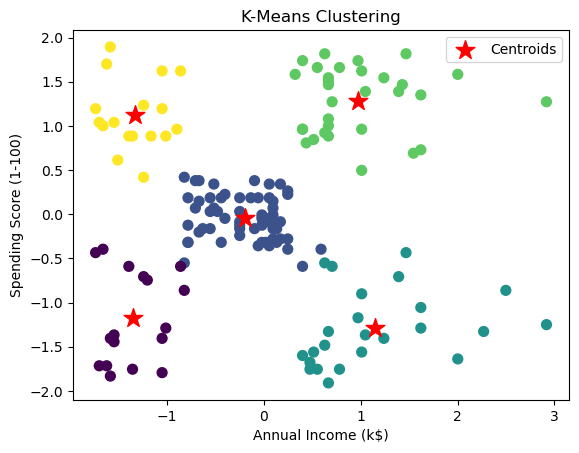

In [8]:
# Step 6: Plot K-Means Clusters
plt.scatter(X_train[:, 0], X_train[:, 1], c=train_labels, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=200, c='red', marker='*', label='Centroids')
plt.title("K-Means Clustering")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

In [9]:
# Step 7: Hierarchical (Agglomerative) Clustering
agg = AgglomerativeClustering(n_clusters=5, linkage='ward')
agg_labels = agg.fit_predict(X_train)
sil_agg = silhouette_score(X_train, agg_labels)
print(f"Agglomerative Silhouette Score: {sil_agg:.3f}")

Agglomerative Silhouette Score: 0.531


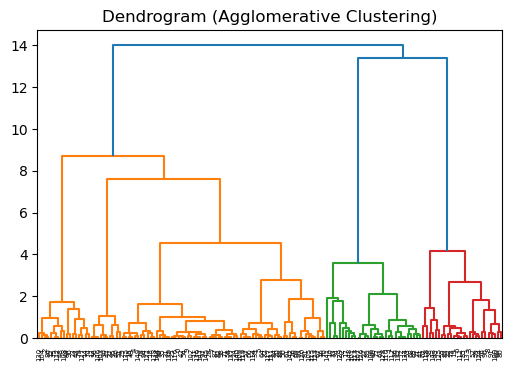

In [10]:

# Dendrogram (for hierarchy visualization)
plt.figure(figsize=(6, 4))
dendrogram(linkage(X_train, method='ward'))
plt.title("Dendrogram (Agglomerative Clustering)")
plt.show()

In [12]:
# Step 8: Cross-validation (Silhouette Score Stability)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []
for train_idx, test_idx in kf.split(X_scaled):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    kmeans = KMeans(n_clusters=5, random_state=42)
    labels = kmeans.fit_predict(X_tr)
    scores.append(silhouette_score(X_tr, labels))
print(f"Cross-Validation Avg Silhouette Score: {np.mean(scores):.3f}")    

Cross-Validation Avg Silhouette Score: 0.533


C:\Users\Anirudh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Anirudh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Anirudh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Anirudh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak o

In [13]:
# Step 9: Conclusion
if sil_kmeans > sil_agg:
    print("\n✅ K-Means performed better based on Silhouette Score.")
else:
    print("\n✅ Agglomerative Clustering performed better based on Silhouette Score.")


✅ K-Means performed better based on Silhouette Score.
